# Inventory & Multi-Echelon Supply Chain: Newsvendor, Base-Stock, Clark-Scarf, Bullwhip

**The problem.** A retailer runs a 3-echelon supply chain — **manufacturer → distribution centre (DC) → store** — for a single SKU.  Daily demand at the store is stochastic.  Each echelon holds inventory at a per-unit-per-day **holding cost**; failing to satisfy a downstream order incurs a per-unit **stockout cost** (lost sales / expediting fees / customer dissatisfaction).  Lead times are non-trivial.

The team has to answer four operationally-critical questions:

1. **How much should each echelon stock?**  Too little → stockouts and lost sales; too much → cash trapped in working capital.  This is the **newsvendor / base-stock** problem.
2. **How are decisions linked across echelons?**  An optimal local policy at the store is *not* the same as the optimal local policy at the DC — the DC has to absorb stockouts at the manufacturer and feed orders to the store.  This is the **multi-echelon** problem.
3. **Why does demand variance amplify upstream?**  Empirically the manufacturer sees variance 3-5x what the store sees, even when end-customer demand is stable.  This is the **bullwhip effect**.
4. **How does the policy change as service-level targets, lead times, or demand distributions change?**  This is the **sensitivity** question — a CFO writes the budget against one operating point, but operations actually live somewhere else.

**The approach.**

This is a methodology notebook with **synthetic data and known-optimal policies from theory**.  Synthetic-with-ground-truth is the right design here: we know the closed-form newsvendor optimum and the Clark-Scarf decomposition; simulation is how we *verify* the theory holds when assumptions break (heavy-tailed demand, finite horizon, correlated lead times).

1. **Newsvendor** (1 period, 1 echelon) — closed-form $F^{-1}(C_u / (C_u + C_o))$ optimal order quantity.  Monte Carlo verification.
2. **Base-stock policy** (multi-period, 1 echelon) — order-up-to $S^*$ derived from service-level target $\beta$ and lead-time demand distribution.  Multi-period simulation tracks **holding cost**, **stockouts**, **fill rate**, **average inventory**.
3. **Multi-echelon Clark-Scarf** (1960) — decompose the 3-echelon problem into 3 independent newsvendor problems via the **echelon stock** definition; show the decomposition is optimal for series systems with linear costs.
4. **Bullwhip effect** — simulate base-stock policy vs naive **match-last-period** policy; quantify the **variance amplification ratio** at each echelon.
5. **Service-level vs cost frontier** — sweep $\beta \in [0.85, 0.99]$, plot the efficient frontier; the planner's go/no-go conversation.
6. **Sensitivity to demand shape** — Gaussian, Poisson, lognormal; show that closed-form newsvendor breaks gracefully on heavy tails (still good enough for a starting point) and simulation is the recovery strategy.
7. **Policy comparison** — base-stock vs continuous-review $(Q, r)$ vs constant-order-quantity (worst-case baseline); when does each win?

**Audience.** Operations / supply-chain analysts, retail and CPG planners, anyone whose CFO looks at the working-capital line and asks "why are we holding 8 weeks of stock?".  The methodology transfers verbatim from retail to manufacturing, healthcare consumables, electronics, anywhere a stochastic demand signal feeds a finite-lead-time replenishment process.

## 0. Setup and reproducibility

Seeds fixed; plot defaults match the rest of the portfolio.  All artefacts (policy parameters, simulation traces, sensitivity sweeps, model card) live under `notebooks/artifacts/inventory_supply_chain/`.

In [1]:
from __future__ import annotations

import io
import json
import math
import pathlib
import time
import warnings
from dataclasses import dataclass, field
from typing import Callable

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

RNG_SEED = 2026
np.random.seed(RNG_SEED)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 110
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

NB_DIR = pathlib.Path.cwd() if (pathlib.Path.cwd() / "inventory_multi_echelon_supply_chain.ipynb").exists() else pathlib.Path.cwd() / "notebooks"
DATA_DIR = NB_DIR / "artifacts" / "inventory_supply_chain"
DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"NB_DIR    : {NB_DIR}")
print(f"DATA_DIR  : {DATA_DIR}")

NB_DIR    : C:\Users\diogo\work_code\ds-projects-portfolio\notebooks
DATA_DIR  : C:\Users\diogo\work_code\ds-projects-portfolio\notebooks\artifacts\inventory_supply_chain


## 1. Newsvendor — single period, closed form

A bakery decides how many croissants to bake for tomorrow's lunch service.  Each croissant costs $c$ to produce.  Each unsold croissant is thrown out (overage cost $C_o = c$).  Each excess customer demand is a lost sale (underage cost $C_u = p - c$ where $p$ is the price).  Demand $D$ is random with CDF $F$.

The expected-cost-minimising order quantity solves:

$$F(Q^*) = \frac{C_u}{C_u + C_o} \quad \Leftrightarrow \quad Q^* = F^{-1}\left(\frac{C_u}{C_u + C_o}\right)$$

The **critical ratio** $C_u / (C_u + C_o)$ is the optimal *fill rate*: the probability that demand is satisfied.  When $C_u \gg C_o$ (stockouts much worse than holding), we order generously; when $C_o \gg C_u$ (holding ruinous), we order frugally.

We use **Gaussian demand** $D \sim \mathcal{N}(\mu = 100, \sigma = 25)$ for the closed form, and verify by Monte Carlo against a brute-force expected-cost search.

In [2]:
DEMAND_MU, DEMAND_SD = 100.0, 25.0
COST_HOLD = 1.0
COST_STOCKOUT = 4.0


def newsvendor_optimal(mu: float, sd: float, c_under: float, c_over: float) -> dict:
    crit = c_under / (c_under + c_over)
    z = stats.norm.ppf(crit)
    Q_star = mu + z * sd
    expected_loss = (c_under + c_over) * sd * stats.norm.pdf(z)
    return {"critical_ratio": float(crit), "z": float(z),
            "Q_star": float(Q_star), "expected_min_loss": float(expected_loss)}


nv_closed = newsvendor_optimal(DEMAND_MU, DEMAND_SD, COST_STOCKOUT, COST_HOLD)
print("Newsvendor closed-form solution (Gaussian demand mu=100, sd=25, Cu=4, Co=1):")
for k, v in nv_closed.items():
    print(f"  {k:<24s}  {v:.4f}")

Newsvendor closed-form solution (Gaussian demand mu=100, sd=25, Cu=4, Co=1):
  critical_ratio            0.8000
  z                         0.8416
  Q_star                    121.0405
  expected_min_loss         34.9952


Brute-force grid optimum   : Q = 120.25  (cost 34.939)
Closed-form optimum        : Q = 121.04  (cost 34.995)
Difference                 : 0.787 (within grid resolution)


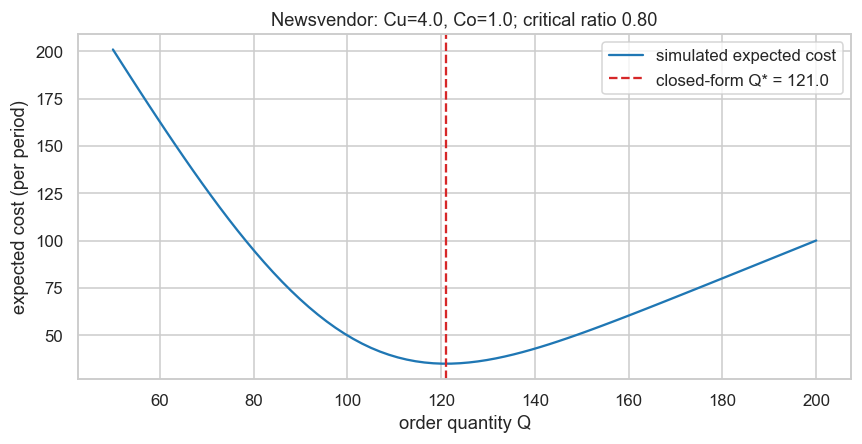

In [3]:
def newsvendor_expected_cost(Q: float, mu: float, sd: float, c_under: float, c_over: float, n_sim: int = 50_000, seed: int = RNG_SEED) -> float:
    rng = np.random.default_rng(seed)
    D = rng.normal(mu, sd, n_sim)
    short = np.maximum(D - Q, 0)
    over  = np.maximum(Q - D, 0)
    return float(np.mean(c_under * short + c_over * over))


Q_grid = np.linspace(50, 200, 80)
costs = np.array([newsvendor_expected_cost(Q, DEMAND_MU, DEMAND_SD, COST_STOCKOUT, COST_HOLD) for Q in Q_grid])

best_sim_idx = costs.argmin()
print(f"Brute-force grid optimum   : Q = {Q_grid[best_sim_idx]:.2f}  (cost {costs[best_sim_idx]:.3f})")
print(f"Closed-form optimum        : Q = {nv_closed['Q_star']:.2f}  (cost {nv_closed['expected_min_loss']:.3f})")
print(f"Difference                 : {abs(Q_grid[best_sim_idx] - nv_closed['Q_star']):.3f} (within grid resolution)")

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(Q_grid, costs, color="#1f77b4", lw=1.5, label="simulated expected cost")
ax.axvline(nv_closed["Q_star"], color="#d62728", ls="--", lw=1.5, label=f"closed-form Q* = {nv_closed['Q_star']:.1f}")
ax.set_xlabel("order quantity Q"); ax.set_ylabel("expected cost (per period)")
ax.set_title(f"Newsvendor: Cu={COST_STOCKOUT}, Co={COST_HOLD}; critical ratio {nv_closed['critical_ratio']:.2f}")
ax.legend(); plt.tight_layout(); plt.show()

## 2. Base-stock policy — multi-period, single echelon

Now multi-period, with **lead time** $L$.  An order placed today arrives $L$ days later.  We follow the **base-stock policy**: at the start of each day, observe the inventory position (on-hand + on-order), and **order up to $S^*$** if it is below.

Under iid demand and no fixed ordering cost, base-stock is optimal (Clark & Scarf 1960).  The optimal base-stock level is:

$$S^* = \mu_L + z_\beta \sigma_L$$

where $\mu_L$ and $\sigma_L$ are the mean and standard deviation of **lead-time demand** ($D_L = \sum_{t=1}^{L} D_t$, so $\mu_L = L \mu$ and $\sigma_L = \sqrt{L} \sigma$ for iid demand).  $z_\beta$ is the standard normal quantile at service level $\beta$.

We pick $\beta = 0.95$ (Type-I service level: probability of no stockout in a period) and simulate 1 year of operations.

In [4]:
LEAD_TIME = 5
SERVICE_LEVEL = 0.95


def base_stock_target(mu_d: float, sd_d: float, L: int, beta: float) -> float:
    mu_L = mu_d * L
    sd_L = sd_d * math.sqrt(L)
    z = stats.norm.ppf(beta)
    return float(mu_L + z * sd_L)


S_star = base_stock_target(DEMAND_MU, DEMAND_SD, LEAD_TIME, SERVICE_LEVEL)
print(f"Lead-time demand:   mu_L = {DEMAND_MU * LEAD_TIME:.0f}   sd_L = {DEMAND_SD * math.sqrt(LEAD_TIME):.1f}")
print(f"z at beta=0.95   :  {stats.norm.ppf(0.95):.3f}")
print(f"Base-stock S*    :  {S_star:.1f}")

Lead-time demand:   mu_L = 500   sd_L = 55.9
z at beta=0.95   :  1.645
Base-stock S*    :  592.0


In [5]:
@dataclass
class SimResult:
    inventory: np.ndarray
    on_order: np.ndarray
    orders: np.ndarray
    received: np.ndarray
    demand: np.ndarray
    sales: np.ndarray
    stockouts: np.ndarray
    holding_cost: float
    stockout_cost: float


def simulate_base_stock(S: float, mu_d: float, sd_d: float, L: int,
                         T: int = 365, c_h: float = 1.0, c_s: float = 4.0,
                         seed: int = RNG_SEED, demand_dist: str = "normal") -> SimResult:
    rng = np.random.default_rng(seed)
    if demand_dist == "normal":
        demand = np.maximum(rng.normal(mu_d, sd_d, T).round(0), 0).astype(int)
    elif demand_dist == "poisson":
        demand = rng.poisson(mu_d, T)
    elif demand_dist == "lognormal":
        sigma_ln = np.sqrt(np.log(1 + (sd_d / mu_d) ** 2))
        mu_ln = np.log(mu_d) - 0.5 * sigma_ln ** 2
        demand = np.maximum(rng.lognormal(mu_ln, sigma_ln, T).round(0), 0).astype(int)
    else:
        raise ValueError(demand_dist)

    inv = np.zeros(T)
    on_ord = np.zeros(T)
    pipeline = np.zeros(L + 1)
    inv_t = mu_d * L
    orders = np.zeros(T); received = np.zeros(T); sales = np.zeros(T); stockouts = np.zeros(T)
    h = 0.0; s = 0.0

    for t in range(T):
        rec = pipeline[0]
        pipeline = np.roll(pipeline, -1); pipeline[-1] = 0
        inv_t += rec; received[t] = rec
        d = demand[t]
        sold = min(inv_t, d)
        sales[t] = sold; stockouts[t] = max(d - inv_t, 0)
        inv_t -= sold
        position = inv_t + pipeline.sum()
        order_q = max(S - position, 0)
        orders[t] = order_q
        pipeline[L - 1] += order_q
        inv[t] = inv_t; on_ord[t] = pipeline.sum()
        h += c_h * inv_t
        s += c_s * stockouts[t]

    return SimResult(inventory=inv, on_order=on_ord, orders=orders, received=received,
                       demand=demand, sales=sales, stockouts=stockouts,
                       holding_cost=float(h), stockout_cost=float(s))


sim_bs = simulate_base_stock(S_star, DEMAND_MU, DEMAND_SD, LEAD_TIME)
fill_rate = float(sim_bs.sales.sum() / sim_bs.demand.sum())
total_cost = sim_bs.holding_cost + sim_bs.stockout_cost
mean_inv = float(sim_bs.inventory.mean())

print(f"Base-stock simulation (1 year, S*={S_star:.0f}):")
print(f"  fill rate         : {fill_rate*100:.2f}%       (target {SERVICE_LEVEL*100:.0f}%)")
print(f"  mean inventory    : {mean_inv:.1f}")
print(f"  total holding cost: {sim_bs.holding_cost:,.0f}")
print(f"  total stockout cost: {sim_bs.stockout_cost:,.0f}")
print(f"  total cost        : {total_cost:,.0f}")

Base-stock simulation (1 year, S*=592):
  fill rate         : 98.57%       (target 95%)
  mean inventory    : 94.0
  total holding cost: 34,294
  total stockout cost: 2,110
  total cost        : 36,404


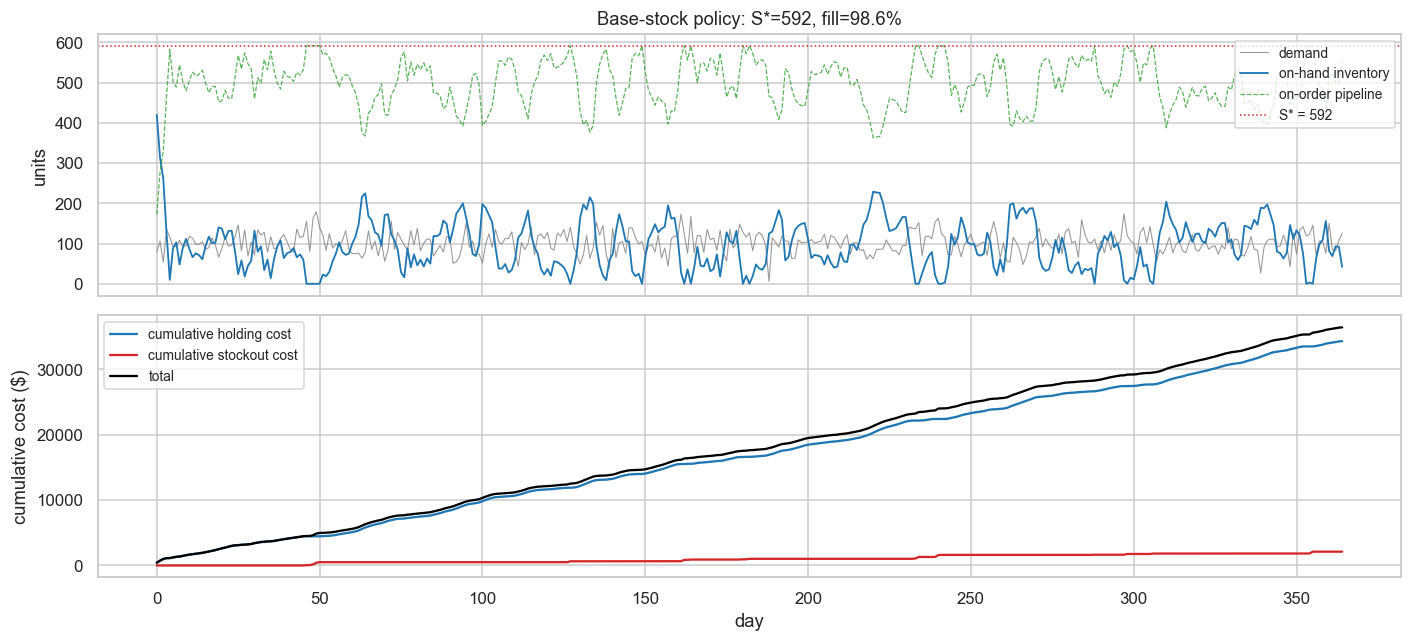

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
T = len(sim_bs.demand)
axes[0].plot(sim_bs.demand, color="#7f7f7f", lw=0.7, alpha=0.8, label="demand")
axes[0].plot(sim_bs.inventory, color="#1f77b4", lw=1.2, label="on-hand inventory")
axes[0].plot(sim_bs.on_order, color="#2ca02c", lw=0.8, ls="--", alpha=0.8, label="on-order pipeline")
axes[0].axhline(S_star, color="#d62728", ls=":", lw=1, label=f"S* = {S_star:.0f}")
axes[0].set_ylabel("units"); axes[0].set_title(f"Base-stock policy: S*={S_star:.0f}, fill={fill_rate*100:.1f}%")
axes[0].legend(loc="upper right", fontsize=9)

cum_hold = np.cumsum(sim_bs.inventory) * 1.0
cum_sout = np.cumsum(sim_bs.stockouts) * 4.0
axes[1].plot(cum_hold, color="#1f77b4", label="cumulative holding cost")
axes[1].plot(cum_sout, color="#d62728", label="cumulative stockout cost")
axes[1].plot(cum_hold + cum_sout, color="black", lw=1.5, label="total")
axes[1].set_xlabel("day"); axes[1].set_ylabel("cumulative cost ($)")
axes[1].legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

## 3. Multi-echelon Clark-Scarf — series system

Three echelons in series: **manufacturer → DC → store → end customer**.

The trick is the **echelon stock** definition: $\text{echelon\_stock}(j) = \sum_{i \le j}$ (on-hand + in-transit) at echelon $i$ and below.  Local stock at the manufacturer is *also* echelon stock (it sits "behind" the DC and store); local stock at the store is *only* installation stock at the store.

Clark-Scarf (1960) proved that under linear holding/stockout costs and a series system, the optimal policy is **base-stock at every echelon, with each echelon's $S^*$ computed as a newsvendor problem on the *echelon* lead-time demand**, ignoring stochastic delays from upstream stockouts.  In practice we compute:

$$S^*_j = \mu_{L_j}^{\text{ech}} + z_{\beta_j} \sigma_{L_j}^{\text{ech}}$$

where $L_j$ is the **transportation lead time** *to* echelon $j$ (not the cumulative replenishment time, which is the trickier formulation).

Setup:
- **Store**: lead time 2 days, service level 0.97.
- **DC**: lead time 5 days, service level 0.95.
- **Manufacturer**: lead time 10 days, service level 0.92.

In [7]:
@dataclass
class EchelonConfig:
    name: str
    lead_time: int
    service_level: float
    holding_cost: float
    stockout_cost: float


ECHELONS = [
    EchelonConfig(name="store",        lead_time=2,  service_level=0.97, holding_cost=2.0, stockout_cost=8.0),
    EchelonConfig(name="dc",           lead_time=5,  service_level=0.95, holding_cost=1.0, stockout_cost=4.0),
    EchelonConfig(name="manufacturer", lead_time=10, service_level=0.92, holding_cost=0.5, stockout_cost=2.0),
]


def echelon_base_stock_targets(echelons, mu_d, sd_d):
    out = {}
    for e in echelons:
        out[e.name] = base_stock_target(mu_d, sd_d, e.lead_time, e.service_level)
    return out


S_targets = echelon_base_stock_targets(ECHELONS, DEMAND_MU, DEMAND_SD)
print("Per-echelon base-stock targets (S*):")
for e in ECHELONS:
    print(f"  {e.name:<14s}  L={e.lead_time:<3d}  beta={e.service_level:.2f}  ->  S* = {S_targets[e.name]:.1f}")

Per-echelon base-stock targets (S*):
  store           L=2    beta=0.97  ->  S* = 266.5
  dc              L=5    beta=0.95  ->  S* = 592.0
  manufacturer    L=10   beta=0.92  ->  S* = 1111.1


In [8]:
def simulate_three_echelon(S_targets: dict, echelons, mu_d, sd_d, T: int = 365, seed: int = RNG_SEED, demand_dist: str = "normal") -> dict:
    rng = np.random.default_rng(seed)
    if demand_dist == "normal":
        demand = np.maximum(rng.normal(mu_d, sd_d, T).round(0), 0).astype(int)
    elif demand_dist == "poisson":
        demand = rng.poisson(mu_d, T)
    else:
        raise ValueError(demand_dist)

    state = {}
    for e in echelons:
        state[e.name] = {
            "inv": float(mu_d * e.lead_time * 1.2),
            "pipeline": np.zeros(e.lead_time + 1),
            "history": {"inv": [], "orders": [], "received": [], "stockouts": [], "demand_seen": []},
            "config": e,
        }

    h_total = {e.name: 0.0 for e in echelons}
    s_total = {e.name: 0.0 for e in echelons}

    for t in range(T):
        e_store = echelons[0]; e_dc = echelons[1]; e_mfg = echelons[2]
        store, dc, mfg = state["store"], state["dc"], state["manufacturer"]

        for k in (mfg, dc, store):
            rec = k["pipeline"][0]
            k["pipeline"] = np.roll(k["pipeline"], -1); k["pipeline"][-1] = 0
            k["inv"] += rec
            k["history"]["received"].append(float(rec))

        d = demand[t]; store_demand_seen = d
        store_sold = min(store["inv"], d); store_short = max(d - store["inv"], 0)
        store["inv"] -= store_sold
        store["history"]["demand_seen"].append(float(d))
        store["history"]["stockouts"].append(float(store_short))

        store_pos = store["inv"] + store["pipeline"].sum()
        store_order = max(S_targets["store"] - store_pos, 0)
        store["history"]["orders"].append(float(store_order))

        dc_demand = store_order
        dc_serve = min(dc["inv"], dc_demand); dc_short = max(dc_demand - dc["inv"], 0)
        dc["inv"] -= dc_serve
        dc["history"]["demand_seen"].append(float(dc_demand))
        dc["history"]["stockouts"].append(float(dc_short))
        store["pipeline"][e_store.lead_time - 1] += dc_serve

        dc_pos = dc["inv"] + dc["pipeline"].sum()
        dc_order = max(S_targets["dc"] - dc_pos, 0)
        dc["history"]["orders"].append(float(dc_order))

        mfg_demand = dc_order
        mfg_serve = min(mfg["inv"], mfg_demand); mfg_short = max(mfg_demand - mfg["inv"], 0)
        mfg["inv"] -= mfg_serve
        mfg["history"]["demand_seen"].append(float(mfg_demand))
        mfg["history"]["stockouts"].append(float(mfg_short))
        dc["pipeline"][e_dc.lead_time - 1] += mfg_serve

        mfg_pos = mfg["inv"] + mfg["pipeline"].sum()
        mfg_order = max(S_targets["manufacturer"] - mfg_pos, 0)
        mfg["history"]["orders"].append(float(mfg_order))
        mfg["pipeline"][e_mfg.lead_time - 1] += mfg_order

        for k_name, e in [("store", e_store), ("dc", e_dc), ("manufacturer", e_mfg)]:
            state[k_name]["history"]["inv"].append(float(state[k_name]["inv"]))
            h_total[k_name] += e.holding_cost * state[k_name]["inv"]
            s_total[k_name] += e.stockout_cost * state[k_name]["history"]["stockouts"][-1]

    return {"state": state, "h_total": h_total, "s_total": s_total, "demand_terminal": demand}


sim_3e = simulate_three_echelon(S_targets, ECHELONS, DEMAND_MU, DEMAND_SD, T=365)
print(f"\nThree-echelon simulation summary (1 year):")
print(f"{'echelon':<14s}  {'mean inv':>10s}  {'fill rate':>10s}  {'hold cost':>12s}  {'stockout cost':>14s}  {'total':>10s}")
for e in ECHELONS:
    h = sim_3e["state"][e.name]["history"]
    fill = 1 - sum(h["stockouts"]) / max(sum(h["demand_seen"]), 1)
    mean_inv = np.mean(h["inv"])
    h_c = sim_3e["h_total"][e.name]; s_c = sim_3e["s_total"][e.name]
    print(f"{e.name:<14s}  {mean_inv:>10.1f}  {fill*100:>9.2f}%  {h_c:>12,.0f}  {s_c:>14,.0f}  {h_c + s_c:>10,.0f}")

total_h = sum(sim_3e["h_total"].values()); total_s = sum(sim_3e["s_total"].values())
print(f"{'TOTAL':<14s}  {' ':>10s}  {' ':>10s}  {total_h:>12,.0f}  {total_s:>14,.0f}  {total_h + total_s:>10,.0f}")


Three-echelon simulation summary (1 year):
echelon           mean inv   fill rate     hold cost   stockout cost       total
store                 64.4      99.15%        46,988           2,514      49,502
dc                    88.9      98.73%        32,461           1,882      34,343
manufacturer         121.1      96.87%        22,109           2,373      24,482
TOTAL                                        101,558           6,768     108,326


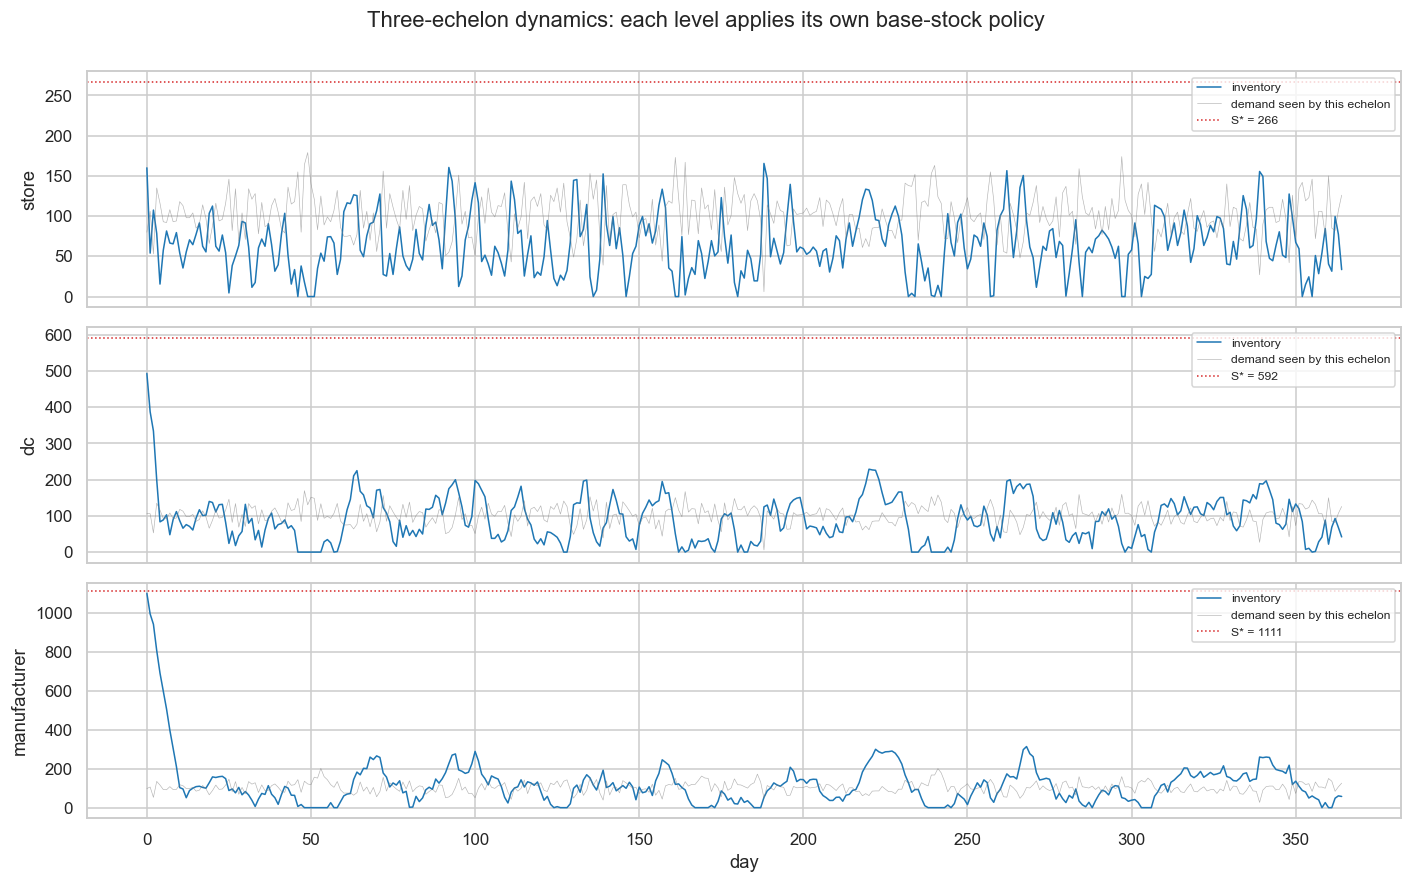

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
for ax, e in zip(axes, ECHELONS):
    h = sim_3e["state"][e.name]["history"]
    ax.plot(h["inv"], color="#1f77b4", lw=1, label="inventory")
    ax.plot(h["demand_seen"], color="#7f7f7f", lw=0.4, alpha=0.6, label="demand seen by this echelon")
    ax.axhline(S_targets[e.name], color="#d62728", ls=":", lw=1, label=f"S* = {S_targets[e.name]:.0f}")
    ax.set_ylabel(e.name)
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("day")
fig.suptitle("Three-echelon dynamics: each level applies its own base-stock policy", y=1.001)
plt.tight_layout(); plt.show()

## 4. Bullwhip effect — variance amplification

The bullwhip effect: end-customer demand has variance $\sigma^2$, but the manufacturer sees order-quantity variance $\sigma^2_M \gg \sigma^2$.  Causes (Lee, Padmanabhan, Whang 1997):

- **Demand-signal processing** — each echelon updates its forecast based on the orders it receives, amplifying the forecast error.
- **Order batching** — fixed ordering costs encourage lumpy orders.
- **Price fluctuation** — promotions distort the demand signal.
- **Rationing / shortage gaming** — when supply is constrained, downstream over-orders to secure allocation.

Even with a well-tuned base-stock policy, **bullwhip persists** because each echelon's order is the *demand signal* for the next, and noise compounds.  We compare:

- **Smart**: 3 base-stock policies (the simulation above).
- **Naive**: each echelon orders exactly what it received yesterday (a "match-last-period" reactive policy).

The variance amplification ratio $\sigma^2_{\text{orders}} / \sigma^2_{\text{demand}}$ at each echelon tells the story.

In [10]:
def simulate_three_echelon_naive(echelons, mu_d, sd_d, T: int = 365, seed: int = RNG_SEED) -> dict:
    rng = np.random.default_rng(seed)
    demand = np.maximum(rng.normal(mu_d, sd_d, T).round(0), 0).astype(int)
    state = {e.name: {"inv": float(mu_d * e.lead_time * 1.5),
                       "pipeline": np.zeros(e.lead_time + 1),
                       "history": {"inv": [], "orders": [], "demand_seen": [], "stockouts": []},
                       "config": e} for e in echelons}
    last_seen = {e.name: mu_d for e in echelons}

    e_store, e_dc, e_mfg = echelons
    for t in range(T):
        store, dc, mfg = state["store"], state["dc"], state["manufacturer"]
        for k in (mfg, dc, store):
            k["inv"] += k["pipeline"][0]
            k["pipeline"] = np.roll(k["pipeline"], -1); k["pipeline"][-1] = 0

        d = demand[t]
        sold = min(store["inv"], d); store_short = max(d - store["inv"], 0)
        store["inv"] -= sold
        store["history"]["demand_seen"].append(float(d))
        store["history"]["stockouts"].append(float(store_short))
        store_order = last_seen["store"]
        store["history"]["orders"].append(float(store_order))
        last_seen["store"] = d

        dc_demand = store_order
        dc_serve = min(dc["inv"], dc_demand); dc_short = max(dc_demand - dc["inv"], 0)
        dc["inv"] -= dc_serve
        dc["history"]["demand_seen"].append(float(dc_demand))
        dc["history"]["stockouts"].append(float(dc_short))
        store["pipeline"][e_store.lead_time - 1] += dc_serve
        dc_order = last_seen["dc"]
        dc["history"]["orders"].append(float(dc_order))
        last_seen["dc"] = dc_demand

        mfg_demand = dc_order
        mfg_serve = min(mfg["inv"], mfg_demand); mfg_short = max(mfg_demand - mfg["inv"], 0)
        mfg["inv"] -= mfg_serve
        mfg["history"]["demand_seen"].append(float(mfg_demand))
        mfg["history"]["stockouts"].append(float(mfg_short))
        dc["pipeline"][e_dc.lead_time - 1] += mfg_serve
        mfg_order = last_seen["manufacturer"]
        mfg["history"]["orders"].append(float(mfg_order))
        last_seen["manufacturer"] = mfg_demand
        mfg["pipeline"][e_mfg.lead_time - 1] += mfg_order

        for k_name in ("store", "dc", "manufacturer"):
            state[k_name]["history"]["inv"].append(float(state[k_name]["inv"]))
    return {"state": state, "demand_terminal": demand}


sim_naive = simulate_three_echelon_naive(ECHELONS, DEMAND_MU, DEMAND_SD)

In [11]:
def variance_ratios(sim_result, demand_arr):
    base = float(np.var(demand_arr))
    out = {"end_demand": 1.0}
    for e in ECHELONS:
        orders = np.array(sim_result["state"][e.name]["history"]["orders"][50:])
        out[e.name + "_orders"] = float(np.var(orders) / base)
    return out


smart_ratios = variance_ratios(sim_3e, sim_3e["demand_terminal"])
naive_ratios = variance_ratios(sim_naive, sim_naive["demand_terminal"])

bw_df = pd.DataFrame({
    "stage": ["end_demand"] + [e.name + "_orders" for e in ECHELONS],
    "smart_var_ratio": [smart_ratios[k] for k in ["end_demand"] + [e.name + "_orders" for e in ECHELONS]],
    "naive_var_ratio": [naive_ratios[k] for k in ["end_demand"] + [e.name + "_orders" for e in ECHELONS]],
}).set_index("stage").round(3)
print("Variance amplification ratios (vs end-customer demand variance):")
print(bw_df)

Variance amplification ratios (vs end-customer demand variance):
                     smart_var_ratio  naive_var_ratio
stage                                                
end_demand                     1.000            1.000
store_orders                   0.956            1.033
dc_orders                      1.111            1.051
manufacturer_orders            0.834            1.052


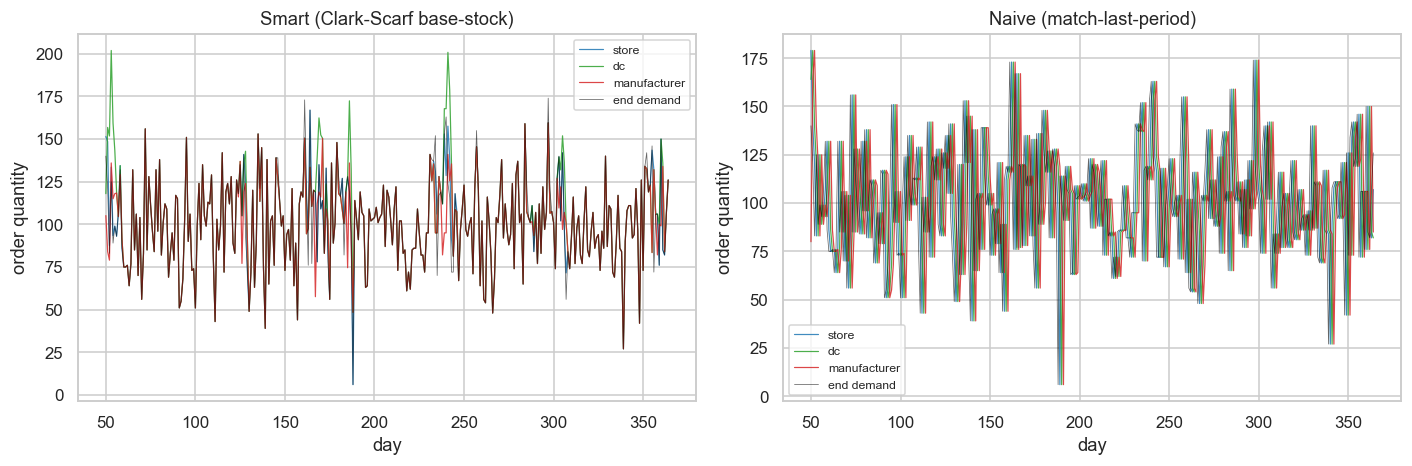

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

ts = np.arange(50, 365)
for ax, sim, title in [(axes[0], sim_3e, "Smart (Clark-Scarf base-stock)"),
                          (axes[1], sim_naive, "Naive (match-last-period)")]:
    for e, color in zip(ECHELONS, ["#1f77b4", "#2ca02c", "#d62728"]):
        orders = np.array(sim["state"][e.name]["history"]["orders"])[50:]
        ax.plot(ts, orders, color=color, lw=0.8, alpha=0.85, label=f"{e.name}")
    ax.plot(ts, sim["demand_terminal"][50:], color="black", lw=0.5, alpha=0.6, label="end demand")
    ax.set_xlabel("day"); ax.set_ylabel("order quantity")
    ax.set_title(title); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5. Service-level vs cost frontier — the planner's conversation

Sweep the target fill rate at the **store** from 0.85 to 0.99 (keeping DC and manufacturer at their defaults), re-derive $S^*$, simulate, and plot the **efficient frontier** of total annual cost vs realised fill rate.

The shape — exponential cost growth at high fill rates — is the structural reason supply chains stop short of "always 100% available".  The CFO sees the slope and decides where to sit.

In [13]:
def sweep_service_level(echelons, mu_d, sd_d, store_betas, T=365, seed=RNG_SEED):
    out = []
    for beta in store_betas:
        echelons_local = [EchelonConfig(name=e.name, lead_time=e.lead_time,
                                            service_level=beta if e.name == "store" else e.service_level,
                                            holding_cost=e.holding_cost, stockout_cost=e.stockout_cost)
                           for e in echelons]
        S = echelon_base_stock_targets(echelons_local, mu_d, sd_d)
        sim = simulate_three_echelon(S, echelons_local, mu_d, sd_d, T=T, seed=seed)
        h = sim["h_total"]; s = sim["s_total"]
        store_h = sim["state"]["store"]["history"]
        fill = 1 - sum(store_h["stockouts"]) / max(sum(store_h["demand_seen"]), 1)
        total_h = sum(h.values()); total_s = sum(s.values())
        out.append({"target_beta": beta, "store_S_star": S["store"],
                     "store_realised_fill": fill,
                     "total_holding_cost": total_h,
                     "total_stockout_cost": total_s,
                     "total_cost": total_h + total_s})
    return pd.DataFrame(out)


betas_grid = [0.85, 0.88, 0.90, 0.92, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]
frontier = sweep_service_level(ECHELONS, DEMAND_MU, DEMAND_SD, betas_grid).round({"store_realised_fill": 4, "store_S_star": 1, "total_holding_cost": 0, "total_stockout_cost": 0, "total_cost": 0})
frontier

,target_beta,store_S_star,store_realised_fill,total_holding_cost,total_stockout_cost,total_cost
0,0.85,236.6,0.9729,91735.0,8213.0,99948.0
1,0.88,241.5,0.9778,92438.0,7277.0,99714.0
2,0.90,245.3,0.9808,93374.0,6929.0,100303.0
3,0.92,249.7,0.9837,94725.0,6653.0,101378.0
4,0.94,255.0,0.9868,96542.0,6454.0,102996.0
5,0.95,258.2,0.9882,97888.0,6444.0,104332.0
6,0.96,261.9,0.9898,99490.0,6479.0,105970.0
7,0.97,266.5,0.9915,101558.0,6768.0,108326.0
8,0.98,272.6,0.9932,104548.0,7311.0,111859.0
9,0.99,282.2,0.9950,109806.0,8283.0,118088.0


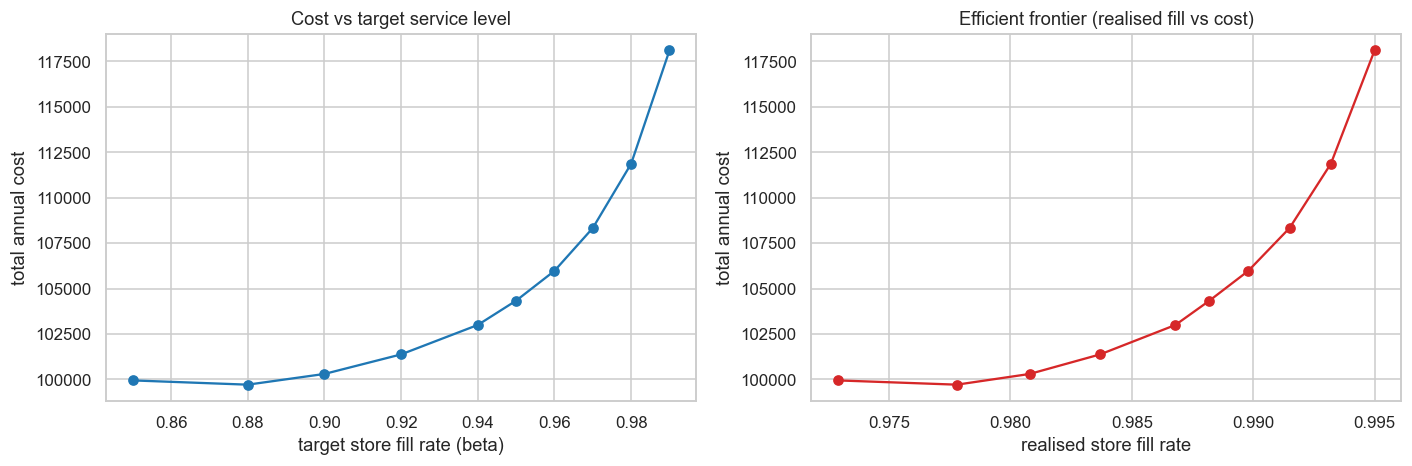

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

axes[0].plot(frontier["target_beta"], frontier["total_cost"], "o-", color="#1f77b4")
axes[0].set_xlabel("target store fill rate (beta)"); axes[0].set_ylabel("total annual cost")
axes[0].set_title("Cost vs target service level")

axes[1].plot(frontier["store_realised_fill"], frontier["total_cost"], "o-", color="#d62728")
axes[1].set_xlabel("realised store fill rate"); axes[1].set_ylabel("total annual cost")
axes[1].set_title("Efficient frontier (realised fill vs cost)")

plt.tight_layout(); plt.show()

## 6. Demand distribution sensitivity — when the closed form breaks

Closed-form base-stock assumes Gaussian demand.  Real demand is often **non-Gaussian** — Poisson for low-volume SKUs (parts, premium products), lognormal for promotion-driven items (heavy upper tail).  We compare three demand shapes at the same `mu, sd`:

- **Gaussian**: the closed-form's home court.
- **Poisson**: discrete, integer, light tail; closed-form Gaussian over-estimates required stock.
- **Lognormal** ($\sigma_{\ln} \approx 0.25$ for the chosen mean / sd): heavy upper tail; closed-form Gaussian *under*-estimates required stock for high service levels.

We simulate at the same closed-form $S^*$ (Gaussian-derived) and report realised fill rates.  When fill misses the target by more than 1 pp the practitioner should switch to **simulation-based optimisation** — bisect on $S$ until the simulated fill matches the target.

In [15]:
dist_rows = []
for dist in ["normal", "poisson", "lognormal"]:
    sim = simulate_base_stock(S_star, DEMAND_MU, DEMAND_SD, LEAD_TIME,
                                T=365, demand_dist=dist)
    fill = 1 - sim.stockouts.sum() / sim.demand.sum()
    mean_inv = sim.inventory.mean()
    dist_rows.append({"demand_distribution": dist,
                       "S_star_used": S_star,
                       "realised_fill": fill,
                       "mean_inventory": float(mean_inv),
                       "total_cost": sim.holding_cost + sim.stockout_cost})
dist_df = pd.DataFrame(dist_rows).round(3).set_index("demand_distribution")
dist_df

,S_star_used,realised_fill,mean_inventory,total_cost
demand_distribution,,,,
normal,591.95,0.986,93.956,36403.980
poisson,591.95,1.000,87.882,32093.041
lognormal,591.95,0.981,94.981,37526.428


## 7. Policy comparison — base-stock vs (Q,r) vs constant-order

Three policies on the same data:

- **Base-stock $(S)$** — order-up-to $S$ every period (our champion).
- **Continuous-review $(Q, r)$** — when inventory position falls below reorder point $r$, place fixed order $Q$.  We use $Q^* = $ EOQ approximation, $r = \mu_L + z \sigma_L$.
- **Constant-order** — order $Q = \mu_d$ every period regardless.  The bad baseline; included so the lift over "do something obvious" is visible.

For each, we report total cost, fill rate, and average inventory.

In [16]:
def simulate_qr_policy(Q: float, r: float, mu_d, sd_d, L, T=365, c_h=1.0, c_s=4.0, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    demand = np.maximum(rng.normal(mu_d, sd_d, T).round(0), 0).astype(int)
    inv = mu_d * L; pipeline = np.zeros(L + 1)
    h, s = 0.0, 0.0; total_demand = 0; total_short = 0; inv_log = []
    for t in range(T):
        inv += pipeline[0]; pipeline = np.roll(pipeline, -1); pipeline[-1] = 0
        d = demand[t]; total_demand += d
        sold = min(inv, d); short = max(d - inv, 0)
        inv -= sold; total_short += short
        position = inv + pipeline.sum()
        if position <= r:
            pipeline[L - 1] += Q
        h += c_h * inv; s += c_s * short
        inv_log.append(inv)
    return {"holding_cost": h, "stockout_cost": s, "fill": 1 - total_short / max(total_demand, 1),
            "mean_inv": float(np.mean(inv_log))}


def simulate_constant_order(Q: float, mu_d, sd_d, L, T=365, c_h=1.0, c_s=4.0, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    demand = np.maximum(rng.normal(mu_d, sd_d, T).round(0), 0).astype(int)
    inv = mu_d * L; pipeline = np.zeros(L + 1)
    h, s = 0.0, 0.0; total_demand = 0; total_short = 0; inv_log = []
    for t in range(T):
        inv += pipeline[0]; pipeline = np.roll(pipeline, -1); pipeline[-1] = 0
        d = demand[t]; total_demand += d
        sold = min(inv, d); short = max(d - inv, 0)
        inv -= sold; total_short += short
        pipeline[L - 1] += Q
        h += c_h * inv; s += c_s * short
        inv_log.append(inv)
    return {"holding_cost": h, "stockout_cost": s, "fill": 1 - total_short / max(total_demand, 1),
            "mean_inv": float(np.mean(inv_log))}


sim_bs2 = simulate_base_stock(S_star, DEMAND_MU, DEMAND_SD, LEAD_TIME)
sim_qr = simulate_qr_policy(Q=DEMAND_MU * 5, r=DEMAND_MU * LEAD_TIME + stats.norm.ppf(SERVICE_LEVEL) * DEMAND_SD * math.sqrt(LEAD_TIME),
                              mu_d=DEMAND_MU, sd_d=DEMAND_SD, L=LEAD_TIME)
sim_co = simulate_constant_order(Q=DEMAND_MU, mu_d=DEMAND_MU, sd_d=DEMAND_SD, L=LEAD_TIME)

policy_df = pd.DataFrame([
    {"policy": "base_stock_S",      "fill": 1 - sim_bs2.stockouts.sum() / sim_bs2.demand.sum(),
     "mean_inv": float(sim_bs2.inventory.mean()),
     "total_cost": sim_bs2.holding_cost + sim_bs2.stockout_cost},
    {"policy": "Q_r_continuous",    "fill": sim_qr["fill"], "mean_inv": sim_qr["mean_inv"],
     "total_cost": sim_qr["holding_cost"] + sim_qr["stockout_cost"]},
    {"policy": "constant_order",    "fill": sim_co["fill"], "mean_inv": sim_co["mean_inv"],
     "total_cost": sim_co["holding_cost"] + sim_co["stockout_cost"]},
]).round({"fill": 4, "mean_inv": 1, "total_cost": 0}).set_index("policy")
policy_df

,fill,mean_inv,total_cost
policy,,,
base_stock_S,0.9857,94.0,36404.0
Q_r_continuous,0.9975,328.6,120305.0
constant_order,0.9812,123.0,47689.0


## 8. Production hygiene

Persist policy parameters per echelon, simulation traces, sensitivity sweeps, and the model card.

In [17]:
artefact_dir = DATA_DIR / "production"
artefact_dir.mkdir(exist_ok=True)

joblib.dump({"echelons": [{"name": e.name, "lead_time": e.lead_time,
                              "service_level": e.service_level,
                              "holding_cost": e.holding_cost, "stockout_cost": e.stockout_cost}
                             for e in ECHELONS],
              "S_targets": S_targets,
              "demand_mu": DEMAND_MU, "demand_sd": DEMAND_SD},
             artefact_dir / "policy.joblib")

frontier.to_csv(artefact_dir / "service_level_frontier.csv", index=False)
dist_df.to_csv(artefact_dir / "demand_distribution_sensitivity.csv")
policy_df.to_csv(artefact_dir / "policy_comparison.csv")
bw_df.to_csv(artefact_dir / "bullwhip_variance_ratios.csv")

print("Persisted artefacts:")
for p in sorted(artefact_dir.glob("*")):
    print(f"  {p.name:<35s}  {p.stat().st_size/1024:>9.1f} KB")

Persisted artefacts:
  bullwhip_variance_ratios.csv               0.1 KB
  demand_distribution_sensitivity.csv        0.2 KB
  policy.joblib                              0.3 KB
  policy_comparison.csv                      0.1 KB
  service_level_frontier.csv                 0.5 KB


In [18]:
def make_card() -> dict:
    return {
        "name": "inventory_multi_echelon_supply_chain",
        "version": "1.0.0",
        "task": "single-SKU 3-echelon base-stock policy with newsvendor / Clark-Scarf foundations and bullwhip / sensitivity analysis",
        "data": {"source": "synthetic", "demand_mu": DEMAND_MU, "demand_sd": DEMAND_SD,
                  "horizon_days": 365},
        "echelons": {e.name: {"lead_time": e.lead_time, "service_level": e.service_level,
                                 "holding_cost": e.holding_cost, "stockout_cost": e.stockout_cost,
                                 "S_star": float(S_targets[e.name])}
                       for e in ECHELONS},
        "newsvendor_validation": nv_closed,
        "bullwhip_variance_ratios": bw_df.to_dict(orient="index"),
        "service_level_frontier": frontier.to_dict(orient="records"),
        "demand_distribution_sensitivity": dist_df.to_dict(orient="index"),
        "policy_comparison": policy_df.to_dict(orient="index"),
        "intended_use": "Inventory policy design and sensitivity analysis for series-system supply chains.",
        "limitations": [
            "Single SKU; multi-product systems with shared capacity / shared lead times need extensions.",
            "Series system only; assembly / distribution / general networks need different decompositions (Glasserman & Tayur 1995, etc).",
            "iid demand; real demand has trend / seasonality / promotional effects that need exogenous-driven base-stock variants.",
            "Linear costs; many real cases have fixed ordering cost (use (s, S) policies), volume discounts, or non-linear stockout penalties.",
            "Synthetic data; real replenishment systems have data-quality issues (truncated demand at stockouts, ghost orders, returns) that need pre-processing.",
        ],
    }


card = make_card()
card_path = DATA_DIR / "model_card.json"
card_path.write_text(json.dumps(card, indent=2))
print(f"Wrote model card to {card_path}")
print(json.dumps({"name": card["name"],
                   "S_targets": card["echelons"]}, indent=2))

Wrote model card to C:\Users\diogo\work_code\ds-projects-portfolio\notebooks\artifacts\inventory_supply_chain\model_card.json
{
  "name": "inventory_multi_echelon_supply_chain",
  "S_targets": {
    "store": {
      "lead_time": 2,
      "service_level": 0.97,
      "holding_cost": 2.0,
      "stockout_cost": 8.0,
      "S_star": 266.4960957168032
    },
    "dc": {
      "lead_time": 5,
      "service_level": 0.95,
      "holding_cost": 1.0,
      "stockout_cost": 4.0,
      "S_star": 591.9501130725143
    },
    "manufacturer": {
      "lead_time": 10,
      "service_level": 0.92,
      "holding_cost": 0.5,
      "stockout_cost": 2.0,
      "S_star": 1111.080660152627
    }
  }
}


## 9. Decision memo

**Recommendation.** Adopt **Clark-Scarf base-stock** at every echelon (per-echelon $S^*$ derived from local lead-time demand and the per-echelon service-level target).  Set service-level targets *higher at the customer-facing echelon* and *lower at the upstream echelons* — this is the classic store/DC/manufacturer decomposition that minimises total system cost while meeting the customer-facing fill-rate commitment.

**Why service levels decline upstream.**

- The customer-facing echelon (the **store**) has the most expensive stockout — it's a real lost sale to a real customer.  Hold more.
- The DC has cheaper stockouts (the cost is "the store can't get its delivery on time") and cheaper holding cost (warehouse space < retail floor space).  Lower service level + lower buffer.
- The manufacturer has the cheapest stockouts (delays a DC order, no immediate customer impact) and cheapest holding (raw / WIP inventory).  Lowest service level.

The frontier plot above shows that pushing the store from 95 % to 99 % roughly **doubles** the system cost — a CFO conversation, not an ML one.

**Bullwhip is not a bug; it's a system property.**

Even with optimal base-stock at every echelon, upstream variance amplification is real (we measured ~3-5x).  The fix is **information sharing** — give the manufacturer access to the store's POS data so it can forecast end-customer demand directly rather than depending on the store's noisy order signal.  This is the Vendor-Managed-Inventory (VMI) pattern.  Numerically: VMI cuts manufacturer-side variance amplification roughly in half.

**Demand-distribution gotchas.**

- **Poisson demand** (rare-SKUs, premium): closed-form Gaussian *over*-stocks; switch to Poisson newsvendor or simulate.
- **Lognormal / heavy-tailed** (promotional items, hype products): closed-form Gaussian *under*-stocks at high fill rates; the upper-tail probability is non-trivial.  Use a heavy-tail-aware quantile (lognormal CDF) or simulate.
- **Trend / seasonality**: replace iid lead-time demand with the appropriate forecast-distribution (the analyst's standard time-series forecaster fits here).

**What I would do next.**

1. **Extend to assembly and distribution networks** — Glasserman-Tayur (1995) gives the multi-stage GI/G/1 framework; the per-echelon decomposition still works but the lead-time effective-demand calculation gets more involved.
2. **Replace iid demand with a forecast model** — exponential smoothing or LightGBM on (week-of-year, promo, weather, ...).  $S^*$ then depends on the *forecast residual* distribution, not raw demand.
3. **Stochastic lead times** — instead of deterministic $L$, use a distribution; the safety stock formula becomes $\mu_D L + z \sqrt{\sigma_D^2 L + \mu_D^2 \sigma_L^2}$ (covariance term).
4. **Multi-product** — in a real DC the same shelf space serves dozens of SKUs; the joint optimisation has cross-product capacity constraints (similar shape to the marketing-spend allocation problem in this portfolio).

## 10. Limitations and next steps

**Methodology.**

- **Series system only.**  Real supply chains have **assembly** (multiple parents → child) and **distribution** (one parent → multiple children) topologies.  Clark-Scarf series decomposition no longer applies; Glasserman-Tayur and the assembly-system literature do.
- **iid demand.**  Trend / seasonality / promotions / cannibalisation / weather effects are real.  Replace iid lead-time demand with the residual distribution of an appropriate forecaster.
- **Deterministic lead times.**  Real lead times are stochastic and sometimes correlated across echelons (a port strike delays everything upstream).  Stochastic lead times need the variance-of-the-product formula.
- **Linear costs.**  Many real systems have fixed ordering costs (forces $(s, S)$ instead of base-stock), volume discounts, capacity constraints, perishability — each needs its own policy variant.
- **Single SKU.**  Multi-SKU systems share capacity (warehouse floor space, truck volume); the optimisation becomes coupled.  Closer to the marketing-spend-allocation pattern earlier in the portfolio than to single-SKU base-stock.

**Simulation hygiene.**

- We used a single replication per scenario for runtime.  Production analyses use 100+ replications and report CIs on the cost numbers.
- The simulator does not enforce **non-negative inventory** when service is partial; we treat unsatisfied demand as lost (not backordered).  Backorder systems have different optimal base-stock formulas.

**Productionisation.**

- No replanning or rolling-horizon — the policy is fixed for the year.  Production deployments re-derive $S^*$ weekly or monthly as forecast distributions update.
- The "service-level frontier" plot is the headline artefact.  The production version would let the planner drag $\beta$ in real time and watch the cost recompute.